## 1. Importación de librerías ##

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

## 2. Datos ##

In [22]:
train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

X_train = train.drop('Churn', axis=1).values
y_train = train['Churn'].values
X_test = test.drop('Churn', axis=1).values
y_test = test['Churn'].values

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5625, 24)  Test: (1407, 24)


## 3. Desbalance de clases y class_weight ##

Antes de entrenar verificamos si las dos clases están equilibradas. Si una clase tiene muchos más clientes que la otra, la red aprende a acertar la clase grande y descuida la pequeña, que aquí es justo la que más nos interesa: los clientes que se van.

Para compensarlo usamos `class_weight`: le damos más peso a la clase con menos clientes, para que equivocarse con un cliente que se va le cueste más a la red.

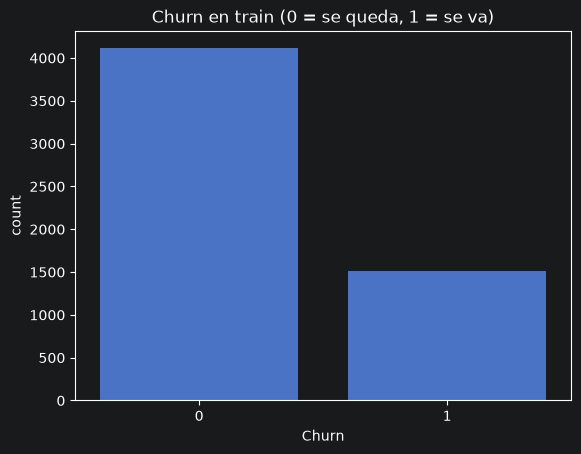

In [23]:
# Verificar si hay una proporción equilibrada entre "0" y "1" #
sns.countplot(x='Churn', data=train)
plt.title("Churn en train (0 = se queda, 1 = se va)")
plt.show()

In [24]:
# Peso de cada clase: total / (2 * cantidad de la clase) #
# La clase con menos clientes recibe más peso #
total = len(y_train)
cantidad_0 = int((y_train == 0).sum())  # clientes que se quedan
cantidad_1 = int((y_train == 1).sum())  # clientes que se van

pesos = {0: total / (2 * cantidad_0), 1: total / (2 * cantidad_1)}

print("Se quedan:", cantidad_0, " Se van:", cantidad_1)
print("Pesos:", pesos)

Se quedan: 4111  Se van: 1514
Pesos: {0: 0.6841401118949161, 1: 1.857661822985469}


## 4. Datos de validación ##

Al entrenar usamos `validation_split=0.2`: Keras aparta el último 20 % de `X_train`, no entrena con esas filas y las usa para medir la pérdida de validación (`val_loss`) en cada época.

Guardamos esas mismas filas en `X_val` y `y_val` para comparar las configuraciones. Así el conjunto de test queda sin tocar hasta la evaluación final.

In [25]:
# validation_split=0.2 separa el último 20 % de X_train para validar #
# Guardamos esas mismas filas para comparar los modelos sin usar el conjunto de test #
corte = int(len(X_train) * 0.8)
X_val = X_train[corte:]
y_val = y_train[corte:]

print("Filas para validar:", len(X_val))

Filas para validar: 1125


## 5. Creación del modelo ##

Seguimos los criterios vistos en clase (Semana 03, "Claves para crear redes neuronales efectivas") y la red del ejemplo de clasificación binaria:

- **Capas ocultas:** se recomienda empezar con 2 o 3. Usamos **2**.
- **Neuronas:** proporcionales al número de variables. Tenemos 24 variables, así que la primera capa tiene **24** neuronas y la segunda la mitad, **12**.
- **Activación:** ReLU en las capas ocultas.
- **Capa de salida:** 1 neurona con **sigmoid**, la que corresponde a clasificación binaria. Da un valor entre 0 y 1; si pasa de 0.5 se predice que el cliente se va.
- **Pérdida y optimizador:** `binary_crossentropy` y Adam.
- **Épocas:** hasta el punto previo al sobreajuste. Ponemos un máximo de 600 y EarlyStopping detiene el entrenamiento cuando `val_loss` lleva 25 épocas sin mejorar.

**Diferencia con el Modelo 2:** aquella red tiene 3 capas ocultas (48 → 24 → 12) y se entrena sin `class_weight`. Esta tiene 2 capas (24 → 12) y sí usa `class_weight`, porque su trabajo es decidir sí o no sin dejar escapar a los clientes que se van.

In [26]:
num_neuronas = X_train.shape[1]
num_neuronas

24

In [27]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

## 6. Efecto de class_weight ##

Entrenamos la misma red dos veces, sin `class_weight` y con `class_weight`, y comparamos los resultados en los datos de validación. Nos fijamos sobre todo en el **recall de la clase 1**: de los clientes que realmente se van, qué porcentaje detecta el modelo.

### 6.1 Sin class_weight ##

In [28]:
tf.keras.utils.set_random_seed(101)  # Para que al volver a ejecutar salgan los mismos resultados #

model_sin_pesos = Sequential()
model_sin_pesos.add(Dense(units=num_neuronas, activation='relu'))
model_sin_pesos.add(Dense(units=int(num_neuronas/2), activation='relu'))
model_sin_pesos.add(Dense(units=1, activation='sigmoid'))
model_sin_pesos.compile(loss='binary_crossentropy', optimizer='adam')

model_sin_pesos.fit(x=X_train, y=y_train, epochs=600,
                    validation_split=0.2,
                    callbacks=[early_stop], verbose=0)

pred_val_sin_pesos = (model_sin_pesos.predict(X_val) > 0.5).astype("int32")
print(classification_report(y_val, pred_val_sin_pesos))

Epoch 35: early stopping
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       830
           1       0.70      0.39      0.50       295

    accuracy                           0.80      1125
   macro avg       0.75      0.66      0.69      1125
weighted avg       0.78      0.80      0.77      1125



### 6.2 Con class_weight (Configuración A: sin Dropout) ###

In [29]:
tf.keras.utils.set_random_seed(101)

model_a = Sequential()
model_a.add(Dense(units=num_neuronas, activation='relu'))
model_a.add(Dense(units=int(num_neuronas/2), activation='relu'))
model_a.add(Dense(units=1, activation='sigmoid'))
model_a.compile(loss='binary_crossentropy', optimizer='adam')

model_a.fit(x=X_train, y=y_train, epochs=600,
            validation_split=0.2,
            class_weight=pesos,
            callbacks=[early_stop], verbose=0)

pred_val_a = (model_a.predict(X_val) > 0.5).astype("int32")
print(classification_report(y_val, pred_val_a))

Epoch 37: early stopping
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       830
           1       0.56      0.65      0.60       295

    accuracy                           0.78      1125
   macro avg       0.71      0.73      0.72      1125
weighted avg       0.79      0.78      0.78      1125



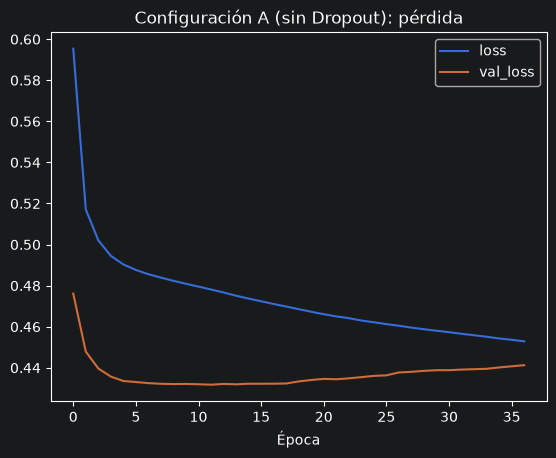

In [30]:
historial_a = pd.DataFrame(model_a.history.history)
historial_a.plot()
plt.title("Configuración A (sin Dropout): pérdida")
plt.xlabel("Época")
plt.show()

historial_a.to_csv("../models/historial_modelo1_sin_dropout.csv", index=False)

**Qué vemos.** Sin `class_weight` el modelo acierta el 80 % de los casos, pero solo detecta el 39 % de los clientes que se van (recall de la clase 1). Acierta mucho porque casi siempre responde "se queda", que es la clase grande.

Con `class_weight` la exactitud baja un poco (78 %), pero el recall sube a 65 %: detecta muchas más fugas. A cambio, la precisión de la clase 1 baja de 0.70 a 0.56, es decir, da más falsas alarmas. Para este modelo preferimos eso, porque dejar ir a un cliente sin detectarlo cuesta más que revisar a uno que no se iba a ir.

En el gráfico, `val_loss` baja hasta la época 12 y después sube poco a poco, mientras `loss` sigue bajando. Esa separación es el inicio del sobreajuste, y EarlyStopping detuvo el entrenamiento en la época 37.

`val_loss` queda por debajo de `loss` porque `class_weight` solo se aplica a la pérdida de entrenamiento. La pérdida de validación se calcula sin pesos.

## 7. Configuración B: con Dropout ##

Dropout apaga al azar una parte de las neuronas en cada paso del entrenamiento. Así la red no puede depender siempre de las mismas neuronas, y eso reduce el sobreajuste. Usamos 0.5 (la mitad de las neuronas de cada capa), como en el ejemplo de clase.

In [31]:
tf.keras.utils.set_random_seed(101)

model_b = Sequential()
model_b.add(Dense(units=num_neuronas, activation='relu'))
model_b.add(Dropout(0.5))  # la mitad de las neuronas en cada paso para esta capa #
model_b.add(Dense(units=int(num_neuronas/2), activation='relu'))
model_b.add(Dropout(0.5))
model_b.add(Dense(units=1, activation='sigmoid'))
model_b.compile(loss='binary_crossentropy', optimizer='adam')

model_b.fit(x=X_train, y=y_train, epochs=600,
            validation_split=0.2,
            class_weight=pesos,
            callbacks=[early_stop], verbose=0)

pred_val_b = (model_b.predict(X_val) > 0.5).astype("int32")
print(classification_report(y_val, pred_val_b))

Epoch 83: early stopping
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.90      0.76      0.82       830
           1       0.53      0.75      0.62       295

    accuracy                           0.76      1125
   macro avg       0.71      0.76      0.72      1125
weighted avg       0.80      0.76      0.77      1125



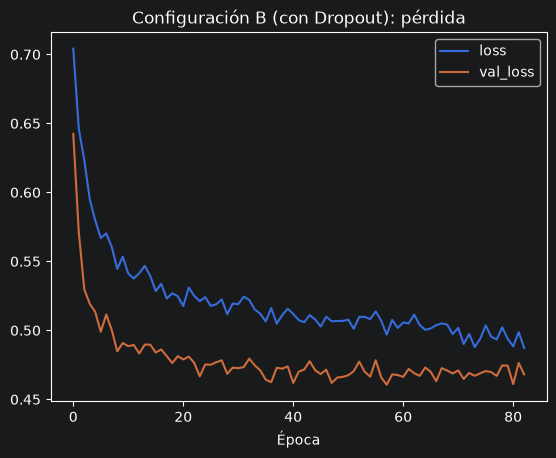

In [32]:
historial_b = pd.DataFrame(model_b.history.history)
historial_b.plot()
plt.title("Configuración B (con Dropout): pérdida")
plt.xlabel("Época")
plt.show()

historial_b.to_csv("../models/historial_modelo1_con_dropout.csv", index=False)

Con Dropout el entrenamiento es más lento y las curvas tienen más saltos, porque en cada paso se apaga la mitad de las neuronas. EarlyStopping lo detuvo en la época 83. `val_loss` se mantiene estable y no aparece la subida que se ve en la Configuración A: no hay señal de sobreajuste.

## 8. Comparación de las configuraciones ##

Comparamos A y B con los datos de validación, sin usar test. Miramos dos cosas: la pérdida de validación de cada una y el `classification_report` de las celdas anteriores.

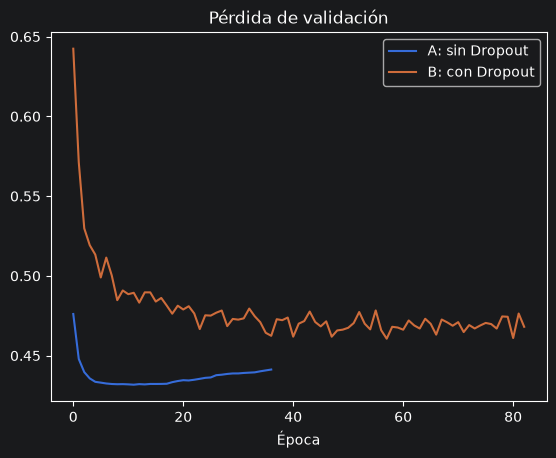

In [33]:
plt.plot(historial_a['val_loss'], label='A: sin Dropout')
plt.plot(historial_b['val_loss'], label='B: con Dropout')
plt.title("Pérdida de validación")
plt.xlabel("Época")
plt.legend()
plt.show()

| | A: sin Dropout | B: con Dropout |
|---|---|---|
| Época de parada | 37 | 83 |
| Exactitud | 0.78 | 0.76 |
| Precisión de la clase 1 | 0.56 | 0.53 |
| Recall de la clase 1 | 0.65 | 0.75 |
| F1 de la clase 1 | 0.60 | 0.62 |

**Qué vemos.**
- La pérdida de validación de A es más baja (≈ 0.44 contra ≈ 0.47). Pero esa pérdida no usa los pesos de `class_weight`: trata igual a las dos clases, así que favorece al modelo que acierta más con los clientes que se quedan.
- En lo que le pedimos al Modelo 1, que es detectar a los que se van, B es mejor: recall de 0.75 contra 0.65 y F1 de 0.62 contra 0.60. Pierde poco en exactitud y en precisión.
- Además, B no muestra sobreajuste, mientras que en A la pérdida de validación empieza a subir desde la época 12.

**Elegimos B (con Dropout).**

In [34]:
model = model_b  # configuración elegida #

## 9. Evaluación final con test ##

Con la configuración ya elegida, evaluamos una sola vez con el conjunto de test, que el modelo no ha visto en ningún momento.

In [35]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, predictions))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1052
           1       0.51      0.74      0.60       355

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.75      0.77      1407



[[798 254]
 [ 92 263]]


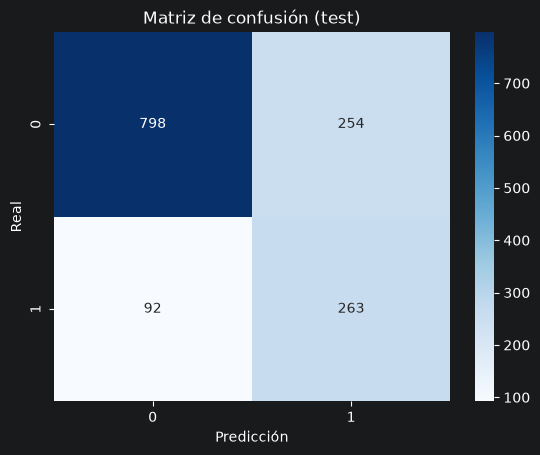

In [36]:
print(confusion_matrix(y_test, predictions))

sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión (test)")
plt.show()

**Lectura.** En test, con datos que el modelo nunca vio:
- Detecta **263 de los 355 clientes que se van** (recall de 0.74). Se le escapan 92.
- Da 254 falsas alarmas: clientes que marcó como fuga y se quedaron. Por eso la precisión de la clase 1 es 0.51: de cada dos alertas, una es correcta.
- La exactitud general es de 75 %.

Los resultados de test son casi iguales a los de validación (recall de 0.75 y F1 de 0.62), así que el modelo generaliza bien.

Comparado con el Modelo 2 usado con el corte de 0.5 (recall de 0.61), este modelo detecta más fugas a cambio de más falsas alarmas. Es lo esperado, porque usa `class_weight`.

## 10. Guardar el modelo ##

Guardamos la configuración elegida en formato Keras, para que la API y el dashboard la carguen sin tener que entrenar de nuevo.

In [37]:
model.save("../models/model1.keras")

## 11. Conclusiones ##

- **Modelo 1:** red de 2 capas ocultas (24 → 12) con Dropout de 0.5, EarlyStopping y `class_weight`.
- **class_weight:** sin él, el modelo solo detecta el 39 % de las fugas en validación. Con él detecta el 65 % (sin Dropout) y el 75 % (con Dropout).
- **Dropout:** evita el sobreajuste que aparece sin él desde la época 12, y en esta comparación dio mejor recall y F1 de la clase 1. Por eso se eligió la Configuración B.
- **Desempeño en test:** exactitud de 75 %, recall de 0.74 y precisión de 0.51 en la clase 1. Detecta 263 de 355 fugas.
- **Costo:** 254 falsas alarmas. Es el precio de detectar más fugas.
- **Archivos para el equipo:** `models/model1.keras` (para la API y el dashboard) y los historiales `models/historial_modelo1_*.csv` (para el notebook 05).